## Task 2: Store and Analyse the Data

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [24]:
df = pd.read_csv("github_projects.csv")

In [25]:
df.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197212,76082,197212,2952,2015-11-07 01:19:20+00:00,2026-08-21 11:36:04+00:00,Apache License 2.0
1,transformers,huggingface,Python,164297,34305,164297,2386,2018-10-29 13:56:00+00:00,2026-08-21 11:36:26+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89643,22017,89643,14,2021-03-03 01:34:05+00:00,2026-08-21 11:24:32+00:00,MIT License
3,funNLP,fighting41love,Python,82578,15271,82578,52,2018-08-21 11:20:39+00:00,2026-08-21 09:14:39+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74093,15617,74093,26,2014-07-15 19:11:19+00:00,2026-08-21 11:29:01+00:00,Other


In [26]:
conn = sqlite3.connect("github_projects.db")

In [27]:
df.to_sql("Repositories", conn, if_exists="replace", index=False)

100

In [28]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name
0,Repositories


In [29]:
query = """
SELECT *
FROM Repositories
LIMIT 5;
"""

result = pd.read_sql_query(query, conn)

result

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197212,76082,197212,2952,2015-11-07 01:19:20+00:00,2026-08-21 11:36:04+00:00,Apache License 2.0
1,transformers,huggingface,Python,164297,34305,164297,2386,2018-10-29 13:56:00+00:00,2026-08-21 11:36:26+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89643,22017,89643,14,2021-03-03 01:34:05+00:00,2026-08-21 11:24:32+00:00,MIT License
3,funNLP,fighting41love,Python,82578,15271,82578,52,2018-08-21 11:20:39+00:00,2026-08-21 09:14:39+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74093,15617,74093,26,2014-07-15 19:11:19+00:00,2026-08-21 11:29:01+00:00,Other


In [30]:
query = """
SELECT name, stars
FROM Repositories
WHERE stars > 10000;
"""

result = pd.read_sql_query(query, conn)

result

,name,stars
0,tensorflow,197212
1,transformers,164297
2,ML-For-Beginners,89643
3,funNLP,82578
4,awesome-machine-learning,74093
...,...,...
65,machine-learning-systems-design,10536
66,Machine-Learning,10371
67,machine-learning-notes,10337
68,3D-Machine-Learning,10191


In [31]:
query = """
SELECT name, stars
FROM Repositories
WHERE name LIKE '%Machine%';
"""

result = pd.read_sql_query(query, conn)

result

,name,stars
0,awesome-machine-learning,74093
1,500-AI-Machine-learning-Deep-learning-Computer...,36425
2,machine-learning-for-software-engineers,28865
3,homemade-machine-learning,24771
4,awesome-production-machine-learning,20858
5,machine-learning-for-trading,20565
6,stanford-cs-229-machine-learning,20138
7,Machine-Learning-Tutorials,18126
8,machine-learning-zoomcamp,13965
9,machine-learning-interview,12787


In [32]:
query = """
SELECT name, stars, forks
FROM Repositories
WHERE stars > 10000
AND forks > 1000;
"""

result = pd.read_sql_query(query, conn)

result

,name,stars,forks
0,tensorflow,197212,76082
1,transformers,164297,34305
2,ML-For-Beginners,89643,22017
3,funNLP,82578,15271
4,awesome-machine-learning,74093,15617
...,...,...,...
64,machine-learning-systems-design,10536,1631
65,Machine-Learning,10371,5065
66,machine-learning-notes,10337,1825
67,3D-Machine-Learning,10191,1797


In [33]:
query = """
SELECT name, stars, forks
FROM Repositories
WHERE stars > 10000
AND forks > 1000;
"""

result = pd.read_sql_query(query, conn)

result

,name,stars,forks
0,tensorflow,197212,76082
1,transformers,164297,34305
2,ML-For-Beginners,89643,22017
3,funNLP,82578,15271
4,awesome-machine-learning,74093,15617
...,...,...,...
64,machine-learning-systems-design,10536,1631
65,Machine-Learning,10371,5065
66,machine-learning-notes,10337,1825
67,3D-Machine-Learning,10191,1797


In [45]:
query = """
SELECT name, language, stars
FROM Repositories
WHERE language = 'Python'
OR language = 'Jupyter Notebook';
"""

result = pd.read_sql_query(query, conn)

result

,name,language,stars
0,transformers,Python,164297
1,ML-For-Beginners,Jupyter Notebook,89643
2,funNLP,Python,82578
3,awesome-machine-learning,Python,74093
4,scikit-learn,Python,66989
5,gradio,Python,43396
6,ML-From-Scratch,Python,32501
7,linkedin-skill-assessments-quizzes,Python,28804
8,cs249r_book,Python,27969
9,shap,Jupyter Notebook,25693


In [34]:
query = """
SELECT name, language
FROM Repositories
WHERE NOT language = 'Python';
"""

result = pd.read_sql_query(query, conn)

result

,name,language
0,tensorflow,C++
1,ML-For-Beginners,Jupyter Notebook
2,500-AI-Machine-learning-Deep-learning-Computer...,Unknown
3,C-Plus-Plus,C++
4,netron,JavaScript
...,...,...
65,Machine-learning-learning-notes,Unknown
66,awesome-youtubers,Markdown
67,Learn_Machine_Learning_in_3_Months,Unknown
68,h2o-3,Jupyter Notebook


In [35]:
query = """
SELECT name, stars
FROM Repositories
ORDER BY stars DESC;
"""

result = pd.read_sql_query(query, conn)

result

,name,stars
0,tensorflow,197212
1,transformers,164297
2,ML-For-Beginners,89643
3,funNLP,82578
4,awesome-machine-learning,74093
...,...,...
95,Machine-learning-learning-notes,7761
96,awesome-youtubers,7732
97,Learn_Machine_Learning_in_3_Months,7604
98,h2o-3,7495


In [36]:
query = """
SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

top_10 = pd.read_sql_query(query, conn)

top_10

,name,stars
0,tensorflow,197212
1,transformers,164297
2,ML-For-Beginners,89643
3,funNLP,82578
4,awesome-machine-learning,74093
5,scikit-learn,66989
6,gradio,43396
7,500-AI-Machine-learning-Deep-learning-Computer...,36425
8,C-Plus-Plus,34591
9,netron,33380


In [37]:
query = """
SELECT COUNT(*) AS total_repositories
FROM Repositories;
"""

result = pd.read_sql_query(query, conn)

result

,total_repositories
0,100


In [38]:
query = """
SELECT AVG(stars) AS average_stars
FROM Repositories;
"""

result = pd.read_sql_query(query, conn)

result

,average_stars
0,20816.6


In [39]:
query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC;
"""

language_analysis = pd.read_sql_query(query, conn)

language_analysis

,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


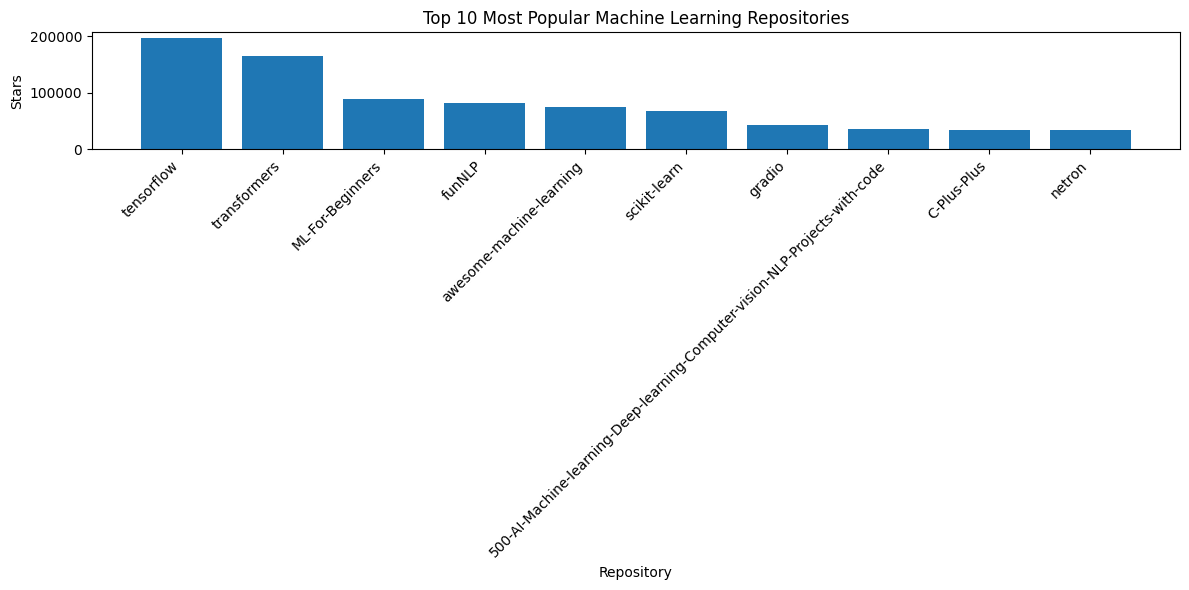

In [40]:
plt.figure(figsize=(12, 6))

plt.bar(top_10["name"], top_10["stars"])

plt.xlabel("Repository")
plt.ylabel("Stars")
plt.title("Top 10 Most Popular Machine Learning Repositories")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [41]:
df["created_date"] = pd.to_datetime(df["created_date"])

In [42]:
df["created_year"] = df["created_date"].dt.year

In [43]:
creation_trends = (
    df.groupby("created_year")
      .size()
      .reset_index(name="repository_count")
)

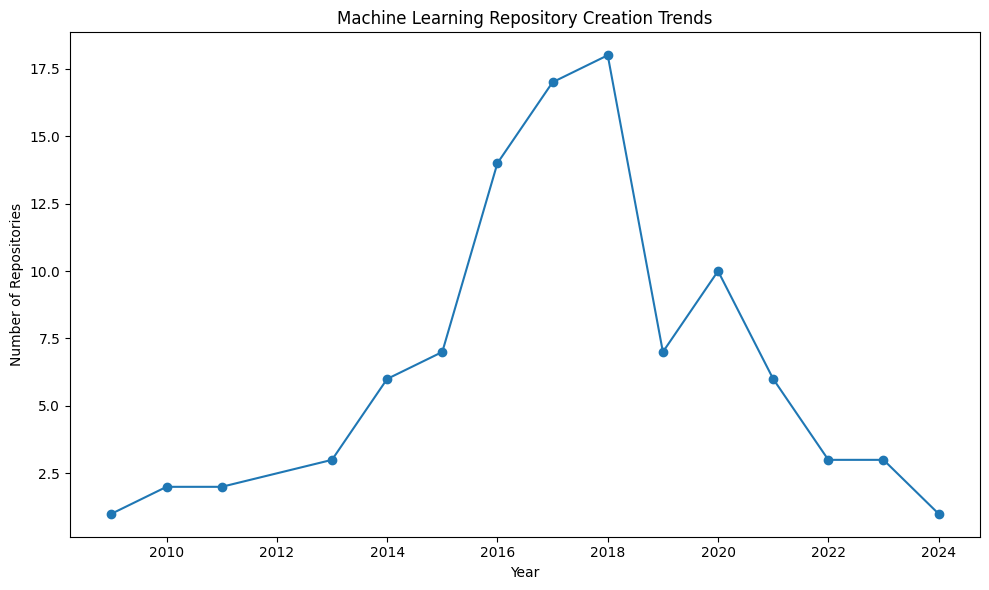

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(
    creation_trends["created_year"],
    creation_trends["repository_count"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Repositories")
plt.title("Machine Learning Repository Creation Trends")

plt.tight_layout()
plt.show()



### Insights

* **TensorFlow is the most popular repository in the dataset**, with **197,212 stars**, followed by **Transformers** with **164,297 stars**. This shows that a small number of well-established Machine Learning projects attract significantly more attention than many other repositories.

* **The popularity of repositories varies considerably.** The top two repositories have much higher star counts than the rest of the Top 10, indicating that GitHub popularity is concentrated among a few leading Machine Learning projects.

* The dataset contains **100 Machine Learning repositories**, with an **average of approximately 20,816.6 stars per repository**. This indicates that the collected repositories are generally highly popular and receive significant attention from the GitHub community.

* The analysis of repository names containing **"Machine"** shows that many repositories in the dataset have Machine Learning directly in their names. Several of these repositories have more than **10,000 stars**, indicating strong interest in educational resources, tutorials, tools, and practical Machine Learning projects.

* The **Top 10 visualization** makes the popularity gap clear: TensorFlow and Transformers stand out significantly, while the remaining repositories have progressively lower star counts. This suggests that repository popularity is not evenly distributed across Machine Learning projects.

* The **repository creation trend** can be used to observe how interest in Machine Learning repositories has changed over time. The distribution of repositories across different years shows that Machine Learning activity on GitHub spans multiple years rather than being limited to a single period.

### Overall Business Insight

**Overall, the analysis shows that Machine Learning is represented by a large range of GitHub projects, but popularity is concentrated in a small number of highly recognized repositories. Projects such as TensorFlow and Transformers have significantly greater community engagement, suggesting that software companies looking for influential Machine Learning technologies should pay particular attention to repositories with high community adoption and activity.**


# Ethics Reflection

## 1. Responsible Data Collection

The repository data was collected using the official GitHub API. Only publicly available repository information required for the analysis was collected. No private user information or sensitive personal data was intentionally collected.

## 2. Data Privacy

The analysis focused on public repository information such as repository names, programming languages, stars, forks, watchers, issues, creation dates, and licenses. Personal or sensitive information was not used in the analysis.

## 3. Data Accuracy

The collected data was cleaned before analysis by handling missing values, removing duplicate records, converting date columns, and extracting required values from nested API fields. These steps helped improve the reliability and accuracy of the analysis.

## 4. Responsible Use of Data

The results should be interpreted carefully because GitHub repository popularity can change over time. High star counts do not necessarily mean that a repository is the best choice for every purpose. The analysis should therefore be used as an indicator of popularity rather than as the only factor in decision-making.

## 5. Ethical Considerations

The project uses data responsibly by limiting the analysis to publicly available information and avoiding unnecessary collection of personal data. The findings are presented based on the available dataset without intentionally misleading or manipulating the results.
